# FanDuel online casino / iGaming research (+ cross-product)

**Question:** Is FanDuel gaining or losing reported **online casino** revenue share, and does that trajectory differ from OSB handle share where both exist?

OSB handle analysis remains in notebook 92. Products are **not** summed. Formal approval remains **MA OSB only**.


## 0. Setup


In [2]:
from __future__ import annotations

import hashlib
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
import sys

sys.path.insert(0, str(ROOT / "src"))
from variant_gaming.storage import connect_readonly

STAGING_DB = ROOT / "data/staging/gaming_nationwide.sqlite"
ORIGINAL_DB = ROOT / "data/gaming.sqlite"
EXPECTED = "023ca5e8e4c16ff0981a2783dabcedf9399939e0241701b0394bc0277eff6ce9"
C_BLUE, C_ORANGE, C_GRAY, C_BLACK = "#0072B2", "#E69F00", "#4D4D4D", "#000000"


def sha256(p: Path) -> str:
    return hashlib.sha256(p.read_bytes()).hexdigest()


h0, s0 = sha256(ORIGINAL_DB), sha256(STAGING_DB)
assert s0 == EXPECTED
print("staging", s0)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 100)


staging 023ca5e8e4c16ff0981a2783dabcedf9399939e0241701b0394bc0277eff6ce9


## 1. Online-casino FanDuel availability / gaps


In [3]:
conn = connect_readonly(STAGING_DB)
raw = pd.read_sql_query(
    """
    SELECT state_code, channel, frequency, row_type, operator, period_start,
           handle, gross_revenue, adjusted_revenue, reported_revenue_name, report_status, source_sha256
    FROM gaming_results WHERE vertical='online_casino'
    """,
    conn,
)
conn.close()
raw["period_start"] = pd.to_datetime(raw["period_start"])

fan = raw[
    raw["row_type"].eq("operator")
    & raw["operator"].str.contains("FanDuel|FANDUEL|Fanduel", case=False, na=False)
]
gaps = []
for st, g in raw.groupby("state_code"):
    f = fan[fan.state_code.eq(st)]
    off = g[g.row_type.eq("official_statewide_total")]
    gaps.append(
        {
            "state": st,
            "channels": ",".join(sorted(g.channel.dropna().unique())),
            "frequency": ",".join(sorted(g.frequency.dropna().unique())),
            "has_official": bool(len(off)),
            "fanduel_native_names": sorted(f.operator.unique()) if len(f) else [],
            "fd_periods": int(f.period_start.nunique()) if len(f) else 0,
            "fd_min": f.period_start.min().date().isoformat() if len(f) else None,
            "fd_max": f.period_start.max().date().isoformat() if len(f) else None,
            "revenue_names": sorted(g.reported_revenue_name.dropna().unique())[:3],
            "decision": (
                "INCLUDE exploratory (MI Adjusted Gross / gross_revenue storage)"
                if st == "MI" and len(f)
                else (
                    "EXCLUDE — FanDuel rows too sparse for Jan–Jul matched window"
                    if st == "NJ" and len(f)
                    else (
                        "EXCLUDE — no FanDuel native identity"
                        if not len(f)
                        else "EXCLUDE — insufficient comparable FanDuel coverage"
                    )
                )
            ),
        }
    )
gap_df = pd.DataFrame(gaps).sort_values("state")
display(Markdown("### Availability / gaps"))
display(gap_df)


### Availability / gaps

,state,channels,frequency,has_official,fanduel_native_names,fd_periods,fd_min,fd_max,revenue_names,decision
0,CT,online,monthly,False,[],0,NaN,NaN,[Total Gross Gaming Revenue],EXCLUDE — no FanDuel native identity
1,DE,online,monthly,True,[],0,NaN,NaN,"[Net, Total Net Gaming Revenue]",EXCLUDE — no FanDuel native identity
2,MI,online,monthly,True,[FanDuel (MotorCity Casino)],67,2021-01-01,2026-07-01,[Adjusted Gross],INCLUDE exploratory (MI Adjusted Gross / gross_revenue storage)
3,NJ,online,monthly,False,[FanDuel],12,2024-01-01,2025-10-01,[Internet Gaming Win],EXCLUDE — FanDuel rows too sparse for Jan–Jul matched window
4,PA,online,monthly,True,[],0,NaN,NaN,[Gross Revenue],EXCLUDE — no FanDuel native identity
5,RI,online,monthly,True,[],0,NaN,NaN,[Net Gaming Revenue (NGR)],EXCLUDE — no FanDuel native identity
6,WV,online,weekly,True,[],0,NaN,NaN,[Revenue],EXCLUDE — no FanDuel native identity


## 2. MI online casino analysis (exploratory)

Metric: stored `gross_revenue` with source label **Adjusted Gross** (same column used for operator and official total; official reconciles to operator sum). No handle in MI casino. Not interchangeable with OSB Accrual Win / handle.


MI casino months available: 67 2021-01-01 → 2026-07-01
Jan–Jul Adjusted Gross share 26.22% → 25.06% (-1.16 pp); FD rev YoY +16.93%; market +22.35%
Accounting decomp: market-growth effect $98,671,579; share effect $-22,208,171; Δ $76,463,408


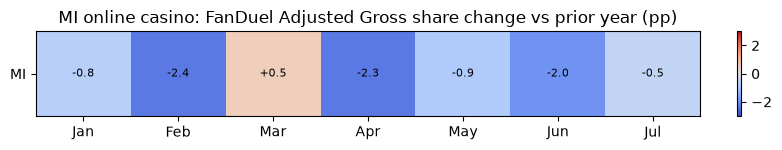

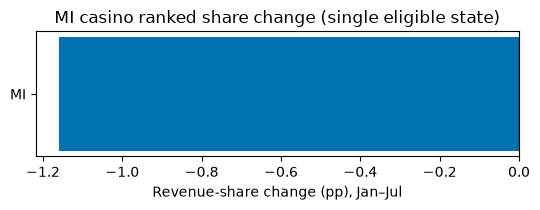

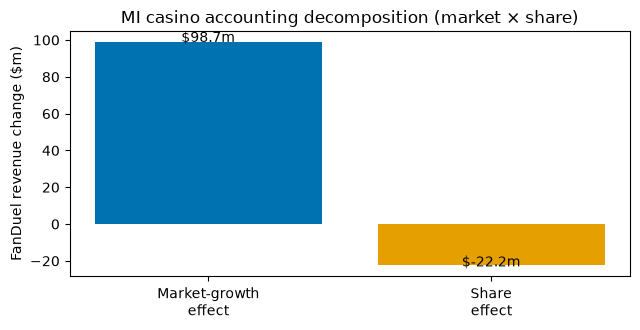

In [4]:
mi = raw[raw.state_code.eq("MI") & raw.channel.eq("online") & raw.frequency.eq("monthly")].copy()
fd_name = "FanDuel (MotorCity Casino)"
PRIOR = [p.to_timestamp() for p in pd.period_range("2025-01", "2025-07", freq="M")]
CURRENT = [p.to_timestamp() for p in pd.period_range("2026-01", "2026-07", freq="M")]
WINDOW = PRIOR + CURRENT

rows = []
for ts in sorted(mi.period_start.unique()):
    f = mi[mi.period_start.eq(ts) & mi.operator.eq(fd_name)]
    o = mi[mi.period_start.eq(ts) & mi.row_type.eq("official_statewide_total")]
    ops = mi[mi.period_start.eq(ts) & mi.row_type.eq("operator")]
    if len(f) != 1 or len(o) != 1:
        continue
    if f.gross_revenue.isna().any() or o.gross_revenue.isna().any() or ops.gross_revenue.isna().any():
        continue
    mkt = float(o.gross_revenue.iloc[0])
    if abs(float(ops.gross_revenue.sum()) - mkt) > 1.0:
        continue
    fd = float(f.gross_revenue.iloc[0])
    rows.append({"month": ts, "fd_rev": fd, "mkt_rev": mkt, "share": fd / mkt, "label": f.reported_revenue_name.iloc[0]})
cas = pd.DataFrame(rows).sort_values("month")
assert set(WINDOW).issubset(set(cas.month))
print("MI casino months available:", len(cas), cas.month.min().date(), "→", cas.month.max().date())


def pooled(months):
    s = cas[cas.month.isin(months)]
    return float(s.fd_rev.sum()), float(s.mkt_rev.sum()), float(s.fd_rev.sum() / s.mkt_rev.sum())


def symmetric_decomp(m0, s0, m1, s1):
    # revenue = market × share
    dm, ds = m1 - m0, s1 - s0
    mkt_effect = dm * (s0 + s1) / 2
    share_effect = ds * (m0 + m1) / 2
    delta = m1 * s1 - m0 * s0
    return mkt_effect, share_effect, delta


fd0, m0, share0 = pooled(PRIOR)
fd1, m1, share1 = pooled(CURRENT)
mkt_fx, sh_fx, delta = symmetric_decomp(m0, share0, m1, share1)
assert abs((mkt_fx + sh_fx) - delta) <= 0.01
print(
    f"Jan–Jul Adjusted Gross share {100*share0:.2f}% → {100*share1:.2f}% ({100*(share1-share0):+.2f} pp); "
    f"FD rev YoY {100*(fd1/fd0-1):+.2f}%; market {100*(m1/m0-1):+.2f}%"
)
print(f"Accounting decomp: market-growth effect ${mkt_fx:,.0f}; share effect ${sh_fx:,.0f}; Δ ${delta:,.0f}")

# monthly share change heatmap (single state)
heat = []
for c, p in zip(CURRENT, PRIOR):
    a = cas[cas.month.eq(c)].iloc[0]
    b = cas[cas.month.eq(p)].iloc[0]
    heat.append({"month": c.strftime("%b"), "share_pp": 100 * (a.share - b.share)})
hdf = pd.DataFrame(heat).set_index("month").T
fig, ax = plt.subplots(figsize=(8.0, 1.6))
im = ax.imshow(hdf.to_numpy(), cmap="coolwarm", aspect="auto", vmin=-3, vmax=3)
ax.set_xticks(range(7), hdf.columns)
ax.set_yticks([0], ["MI"])
for j, v in enumerate(hdf.iloc[0]):
    ax.text(j, 0, f"{v:+.1f}", ha="center", va="center", fontsize=8)
ax.set_title("MI online casino: FanDuel Adjusted Gross share change vs prior year (pp)")
fig.colorbar(im, ax=ax, fraction=0.05)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(5.5, 2.2))
ax.barh(["MI"], [100 * (share1 - share0)], color=C_ORANGE if share1 > share0 else C_BLUE)
ax.axvline(0, color=C_BLACK, linewidth=0.8)
ax.set_xlabel("Revenue-share change (pp), Jan–Jul")
ax.set_title("MI casino ranked share change (single eligible state)")
fig.tight_layout()
plt.show()

# waterfall-ish decomp bars
fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.bar([0, 1], [mkt_fx / 1e6, sh_fx / 1e6], color=[C_BLUE, C_ORANGE])
ax.set_xticks([0, 1], ["Market-growth\neffect", "Share\neffect"])
ax.set_ylabel("FanDuel revenue change ($m)")
ax.set_title("MI casino accounting decomposition (market × share)")
for i, v in enumerate([mkt_fx, sh_fx]):
    ax.text(i, v / 1e6 + (0.3 if v >= 0 else -0.8), f"${v/1e6:.1f}m", ha="center")
fig.tight_layout()
plt.show()


## 3. Cross-product comparison (MI only — common coverage)


In [5]:
# OSB MI from staging (handle share) — exploratory native identity
osb = pd.read_sql_query(
    """
    SELECT period_start, operator, row_type, handle
    FROM gaming_results
    WHERE state_code='MI' AND vertical='online_sports_betting' AND channel='online' AND frequency='monthly'
      AND period_start >= '2025-01-01' AND period_start <= '2026-07-01'
    """,
    connect_readonly(STAGING_DB),
)
osb["period_start"] = pd.to_datetime(osb["period_start"])


def osb_pooled(months):
    fd = osb[osb.period_start.isin(months) & osb.operator.eq(fd_name)]
    off = osb[osb.period_start.isin(months) & osb.row_type.eq("official_statewide_total")]
    return float(fd.handle.sum()), float(off.handle.sum())


ofd0, om0 = osb_pooled(PRIOR)
ofd1, om1 = osb_pooled(CURRENT)
cross = pd.DataFrame(
    [
        {
            "state": "MI",
            "OSB_handle_share_pp": 100 * (ofd1 / om1 - ofd0 / om0),
            "iGaming_revenue_share_pp": 100 * (share1 - share0),
            "OSB_rel_handle_growth_pp": 100 * (ofd1 / ofd0 - 1) - 100 * (om1 / om0 - 1),
            "iGaming_rel_revenue_growth_pp": 100 * (fd1 / fd0 - 1) - 100 * (m1 / m0 - 1),
            "caveats": "OSB=handle share; iGaming=Adjusted Gross revenue share; measures not economically equivalent",
        }
    ]
)
display(Markdown("### Common-coverage direction table"))
display(cross)
print(
    "Observation (directional agreement): both MI products lose reported share Jan–Jul "
    f"(OSB handle-share {100*(ofd1/om1-ofd0/om0):+.2f} pp; iGaming Adjusted Gross share "
    f"{100*(share1-share0):+.2f} pp). Differing share-point magnitudes are **not** equivalent "
    "economic impacts across OSB handle vs casino adjusted revenue."
)
print(
    "Hypothesis only: promotional intensity or product-mix differences — not identified from these tables."
)


### Common-coverage direction table

,state,OSB_handle_share_pp,iGaming_revenue_share_pp,OSB_rel_handle_growth_pp,iGaming_rel_revenue_growth_pp,caveats
0,MI,-4.948575,-1.160153,-14.444742,-5.412627,OSB=handle share; iGaming=Adjusted Gross revenue share; measures not economically equivalent


Observation (directional agreement): both MI products lose reported share Jan–Jul (OSB handle-share -4.95 pp; iGaming Adjusted Gross share -1.16 pp). Differing share-point magnitudes are **not** equivalent economic impacts across OSB handle vs casino adjusted revenue.
Hypothesis only: promotional intensity or product-mix differences — not identified from these tables.


## 4. Findings + integrity


In [6]:
lines = [
    "**Casino coverage:** only MI currently supports a matched Jan–Jul FanDuel online-casino revenue-share analysis. NJ FanDuel casino rows are sparse; PA/CT/DE/WV/RI lack FanDuel native identity in staging.",
    f"**MI iGaming:** Jan–Jul Adjusted Gross share {100*share0:.2f}% → {100*share1:.2f}% ({100*(share1-share0):+.2f} pp); market growth dominates the accounting decomposition.",
    (
        f"**Cross-product (MI):** directional agreement on share loss — OSB handle-share "
        f"{100*(ofd1/om1-ofd0/om0):+.2f} pp vs iGaming revenue-share {100*(share1-share0):+.2f} pp. "
        "Do not treat the pp gap as comparable economic impact across products/metrics."
    ),
    (
        "**Missing data by question:** "
        "(1) **recovery durability** — post-July 2026 months; "
        "(2) **cross-product breadth** — brand-level FanDuel casino in NJ/PA with complete 2025–26 months; "
        "(3) **sports-mix attribution** — sport-level OSB handle; "
        "(4) **denominator confidence** — printed IN statewide OSB totals."
    ),
]
display(Markdown("### Findings"))
for ln in lines:
    display(Markdown("- " + ln))
assert sha256(ORIGINAL_DB) == h0 and sha256(STAGING_DB) == s0
print("DB hashes unchanged")
print(f"hash_staging={s0}")
print(f"hash_original={h0}")


### Findings

- **Casino coverage:** only MI currently supports a matched Jan–Jul FanDuel online-casino revenue-share analysis. NJ FanDuel casino rows are sparse; PA/CT/DE/WV/RI lack FanDuel native identity in staging.

- **MI iGaming:** Jan–Jul Adjusted Gross share 26.22% → 25.06% (-1.16 pp); market growth dominates the accounting decomposition.

- **Cross-product (MI):** directional agreement on share loss — OSB handle-share -4.95 pp vs iGaming revenue-share -1.16 pp. Do not treat the pp gap as comparable economic impact across products/metrics.

- **Missing data by question:** (1) **recovery durability** — post-July 2026 months; (2) **cross-product breadth** — brand-level FanDuel casino in NJ/PA with complete 2025–26 months; (3) **sports-mix attribution** — sport-level OSB handle; (4) **denominator confidence** — printed IN statewide OSB totals.

DB hashes unchanged
hash_staging=023ca5e8e4c16ff0981a2783dabcedf9399939e0241701b0394bc0277eff6ce9
hash_original=62afd2b97459f151e62fbbf24c7e0d0fe5a52e9dee829931d2554b9b1529d388
